# 함수의 연속

$f$가 $x=a$에서 **연속**이란:

1. $f(a)$가 정의되고
2. $\displaystyle\lim_{x\to a} f(x)$가 존재하며
3. $\displaystyle\lim_{x\to a} f(x) = f(a)$

한 점에서 연속이 아니면 **불연속**이다.

## 1. 연속 판정 (sympy)

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

sp.init_printing()
x = sp.symbols('x')

def check_continuity(expr, a, f_at_a=None):
    """f_at_a를 주면 그 값을 f(a)로 사용 (재정의 가능)."""
    lim = sp.limit(expr, x, a)
    val = f_at_a if f_at_a is not None else expr.subs(x, a)
    ok = (lim == val) and lim.is_real
    print(f"a = {a}")
    print("  lim =", lim)
    print("  f(a) =", val)
    print("  연속?:", bool(ok))
    return ok

# 다항식은 모든 실수에서 연속
poly = x**2 - 3*x + 1
check_continuity(poly, 2)

a = 2
  lim = -1
  f(a) = -1
  연속?: True


True

**sp.limit / .subs**: <br>
=> 극한과 함숫값을 각각 구해 비교

**다항식 · 유리함수**: <br>
=> 다항식은 $\mathbb{R}$에서 연속. 유리함수는 분모 $\neq 0$인 곳에서 연속

## 2. 불연속의 유형

| 유형 | 특징 | 예 |
|------|------|-----|
| 제거 가능 | 극한 존재, $f(a)$만 다름/미정의 | $(x^2-1)/(x-1)$ at $x=1$ |
| 껑충(도약) | 좌·우극한 존재하나 서로 다름 | 단위계단 |
| 무한 | 좌 또는 우가 $\pm\infty$ | $1/x$ at $0$ |

In [2]:
# (1) 제거 가능
g = (x**2 - 1) / (x - 1)
print("=== 제거 가능 불연속 ===")
print("lim:", sp.limit(g, x, 1))
try:
    print("g(1):", g.subs(x, 1))
except Exception as e:
    print("g(1): 미정의 —", type(e).__name__)

# 재정의하면 연속: h(1)=2
h = sp.Piecewise((x + 1, x != 1), (2, True))
check_continuity(h, 1)

# (2) 도약
step = sp.Piecewise((0, x < 0), (1, True))
print("\n=== 도약 불연속 ===")
print("좌:", sp.limit(step, x, 0, dir='-'))
print("우:", sp.limit(step, x, 0, dir='+'))

# (3) 무한
print("\n=== 무한 불연속 ===")
print("1/x → 0⁺:", sp.limit(1/x, x, 0, dir='+'))

=== 제거 가능 불연속 ===
lim: 2
g(1): nan
a = 1
  lim = 2
  f(a) = 2
  연속?: True

=== 도약 불연속 ===
좌: 1
우: 1

=== 무한 불연속 ===
1/x → 0⁺: oo


## 3. 구간에서의 연속 · 사잇값 정리 (짧게)

$f$가 $[a,b]$에서 연속이고 $f(a) \neq f(b)$이면, $f(a)$와 $f(b)$ 사이의 임의의 $k$에 대해

$$
f(c) = k \quad (a < c < b)
$$

인 $c$가 적어도 하나 있다.

In [3]:
f = (x - 1)*(x - 2)*(x - 3)
a, b = sp.Rational(1, 2), sp.Rational(16, 5)  # 0.5, 3.2
fa, fb = f.subs(x, a), f.subs(x, b)

print(f"f({a}) = {fa}, f({b}) = {fb}")
# k=0이 fa, fb 사이인지
k = 0
print(f"0이 [{min(fa,fb)}, {max(fa,fb)}] 사이?:", min(fa, fb) <= k <= max(fa, fb))

# 근 찾기 (사잇값 → 해 존재)
roots = sp.solve(sp.Eq(f, k), x)
roots_in = [r for r in roots if a < r < b]
print("구간 안 근:")
display(roots_in)

f(1/2) = -15/8, f(16/5) = 66/125
0이 [-15/8, 66/125] 사이?: True
구간 안 근:


## 4. 그래프: 연속 vs 구멍

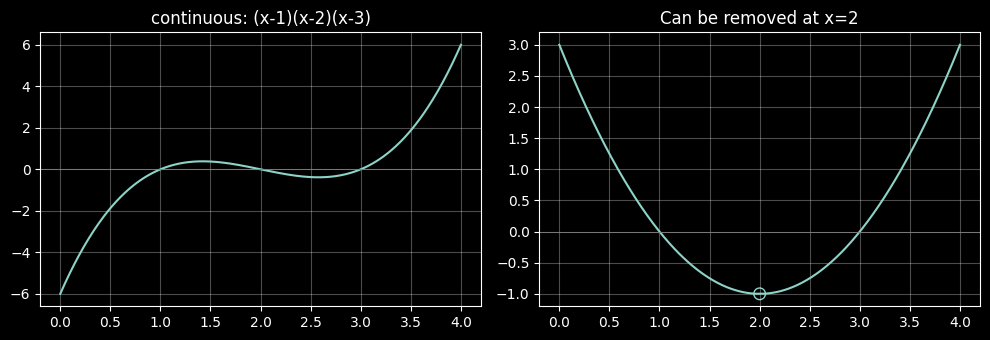

In [6]:
xs = np.linspace(0, 4, 500)
# 연속: 다항식
ys_poly = (xs - 1)*(xs - 2)*(xs - 3)

# 구멍: (x-2)를 약분한 형태와 비슷하게 x=2만 비우기
xs_hole = xs[np.abs(xs - 2) > 0.03]
ys_hole = (xs_hole - 1)*(xs_hole - 3)  # (x-1)(x-3), x≠2에서 (x-1)(x-2)(x-3)/(x-2)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(xs, ys_poly)
axes[0].set_title("continuous: (x-1)(x-2)(x-3)")
axes[0].axhline(0, color="gray", lw=0.6)
axes[0].grid(True, alpha=0.3)

axes[1].plot(xs_hole, ys_hole)
axes[1].scatter([2], [(2-1)*(2-3)], facecolors="none", edgecolors="C0", s=70)
axes[1].set_title("Can be removed at x=2")
axes[1].axhline(0, color="gray", lw=0.6)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()